# EgoRecall — 04B: Visual Retrieval Baseline (Subset)

**Option B — Self-contained, no VM required.**  
Evaluates retrieval on a random subset of 500 val clips.
Extracts index frames on-the-fly from source videos in GCS.

**Use this notebook if:**
- You want results quickly without waiting for the VM embedding job
- You want to experiment with different models or parameters
- You are running in parallel with the full Option A evaluation

**Estimated runtime:** ~1-2 hours on Colab T4 GPU

**Models compared:**
| Model | Embedding Dim | Index Type |
|-------|--------------|------------|
| CLIP (ViT-B/32) | 512 | FAISS FlatIP (cosine) |
| BLIP ITM (base) | 768 | FAISS FlatIP (cosine) |

**Evaluation metric:** Top-1 frame retrieval accuracy  
Success = retrieved frame falls within ±5 seconds of the response track temporal window


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 0 · Imports & Config

In [2]:
!pip install faiss-cpu transformers torch torchvision \
    google-cloud-storage tqdm pandas pyarrow opencv-python-headless --quiet

In [3]:
import faiss
import torch

print("faiss version:", faiss.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

faiss version: 1.13.2
CUDA available: True
GPU: Tesla T4


In [4]:
import json
import io
import os
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from google.cloud import storage
from transformers import (
    CLIPProcessor, CLIPModel,
    BlipProcessor, BlipForImageTextRetrieval
)

# ── GCS config ─────────────────────────────────────────────────────────────
BUCKET_NAME = "egorecall-data"

# ── Local paths ────────────────────────────────────────────────────────────
WORK_DIR    = Path("/content/egorecall_retrieval_subset")
RESULTS_DIR = Path("/content/results/retrieval_subset")
TMP_DIR     = Path("/tmp/retrieval_work")
for d in [WORK_DIR, RESULTS_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Subset config ──────────────────────────────────────────────────────────
N_CLIPS      = 10       # number of val clips to evaluate on
RANDOM_SEED  = 42

# ── Model config ───────────────────────────────────────────────────────────
CLIP_MODEL   = "openai/clip-vit-base-patch32"
BLIP_MODEL   = "Salesforce/blip-itm-base-coco"
BATCH_SIZE   = 64

# ── Evaluation config ──────────────────────────────────────────────────────
VIDEO_FPS        = 30
INDEX_STRIDE     = 30    # 1 FPS
TOLERANCE_SEC    = 5
TOLERANCE_FRAMES = TOLERANCE_SEC * VIDEO_FPS

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


## 1 · Authentication & GCS

In [5]:
from google.colab import auth
auth.authenticate_user()

gcs_client = storage.Client()
bucket     = gcs_client.bucket(BUCKET_NAME)
print(f"Connected to gs://{BUCKET_NAME}")

Connected to gs://egorecall-data


In [6]:
# ── Load annotations ──────────────────────────────────────────────────────
bucket.blob("processed/vq_query_sets.parquet").download_to_filename("/tmp/vq_query_sets.parquet")
bucket.blob("ego4d/v2/annotations/vq_val.json").download_to_filename("/tmp/vq_val.json")

df = pd.read_parquet("/tmp/vq_query_sets.parquet")
with open("/tmp/vq_val.json") as f:
    val_raw = json.load(f)

val_df = df[df["split"] == "val"].copy()
print(f"Val query-sets : {len(val_df):,}")
print(f"Val clips      : {val_df['clip_uid'].nunique():,}")

Val query-sets : 4,507
Val clips      : 1,157


## 2 · Sample Subset & Build Workplan

In [7]:
# ── Sample N_CLIPS random val clips ───────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

all_val_clips = val_df["clip_uid"].unique().tolist()
subset_clips  = random.sample(all_val_clips, min(N_CLIPS, len(all_val_clips)))
subset_df     = val_df[val_df["clip_uid"].isin(subset_clips)].copy()

print(f"Sampled clips     : {len(subset_clips):,}")
print(f"Query-sets in subset: {len(subset_df):,}")

Sampled clips     : 10
Query-sets in subset: 38


In [8]:
# ── Build workplan: clip_uid → video info + query-sets ────────────────────
# Maps clip_uid → {video_uid, video_start_frame, video_end_frame, query_sets}
workplan = {}
rt_lookup = {}  # (annotation_uid, qs_id) → [video_frame_numbers]

for video in val_raw["videos"]:
    vid = video["video_uid"]
    for clip in video["clips"]:
        cuid = clip["clip_uid"]
        if cuid not in subset_clips:
            continue

        workplan[cuid] = {
            "video_uid"         : vid,
            "video_start_frame" : clip["video_start_frame"],
            "video_end_frame"   : clip["video_end_frame"],
            "query_sets"        : [],
        }

        for anno in clip["annotations"]:
            for qs_id, qs in anno["query_sets"].items():
                if not qs.get("is_valid"):
                    continue
                vc = qs["visual_crop"]
                workplan[cuid]["query_sets"].append({
                    "annotation_uid"  : anno["annotation_uid"],
                    "qs_id"           : qs_id,
                    "vc_blob"         : (
                        f"frames/retrieval/visual_crops/val/{cuid}/"
                        f"{anno['annotation_uid']}_{qs_id}.jpg"
                    ),
                    "object_title"    : qs.get("object_title", "").strip().lower(),
                })
                key = (anno["annotation_uid"], qs_id)
                rt_lookup[key] = [
                    b["video_frame_number"]
                    for b in qs.get("response_track", [])
                ]

print(f"Workplan clips : {len(workplan):,}")
print(f"RT entries     : {len(rt_lookup):,}")

Workplan clips : 10
RT entries     : 38


## 3 · Load Models

In [9]:
print("Loading CLIP...")
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE)
clip_model.eval()

print("Loading BLIP...")
blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL)
blip_model     = BlipForImageTextRetrieval.from_pretrained(BLIP_MODEL).to(DEVICE)
blip_model.eval()

print("Models loaded.")

Loading CLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading BLIP...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

BlipForImageTextRetrieval LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_encoder.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


In [10]:
# ── Robust helper functions ────────────────────────────────────────────────
import torch
import numpy as np
import cv2
from PIL import Image

def _to_feature_tensor(output):
    """
    Convert Hugging Face model output object into a tensor embedding.
    Handles different output formats safely.
    """
    if isinstance(output, torch.Tensor):
        return output

    if hasattr(output, "image_embeds") and output.image_embeds is not None:
        return output.image_embeds

    if hasattr(output, "pooler_output") and output.pooler_output is not None:
        return output.pooler_output

    if hasattr(output, "last_hidden_state") and output.last_hidden_state is not None:
        return output.last_hidden_state[:, 0, :]

    raise ValueError(f"Cannot extract tensor from output type: {type(output)}")


def embed_images(images, batch_size=BATCH_SIZE):
    """
    Embed a list of PIL images with both CLIP and BLIP.
    Returns (clip_embs, blip_embs), both L2-normalized float32 numpy arrays.
    """
    clip_embs, blip_embs = [], []

    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]

        with torch.no_grad():
            # ----- CLIP -----
            c_in = clip_processor(
                images=batch,
                return_tensors="pt",
                padding=True
            ).to(DEVICE)

            c_out = clip_model.get_image_features(**c_in)
            c_feat = _to_feature_tensor(c_out)
            c_feat = c_feat / c_feat.norm(dim=-1, keepdim=True)
            clip_embs.append(c_feat.detach().cpu().numpy())

            # ----- BLIP -----
            b_in = blip_processor(
                images=batch,
                return_tensors="pt",
                padding=True
            ).to(DEVICE)

            # Only pass pixel_values into the BLIP vision encoder.
            b_out = blip_model.vision_model(pixel_values=b_in["pixel_values"])
            b_feat = _to_feature_tensor(b_out)
            b_feat = b_feat / b_feat.norm(dim=-1, keepdim=True)
            blip_embs.append(b_feat.detach().cpu().numpy())

    return (
        np.vstack(clip_embs).astype(np.float32),
        np.vstack(blip_embs).astype(np.float32)
    )


def extract_frames_sequential(video_path, frame_numbers):
    """
    Extract selected frames from a local video file using OpenCV.
    Returns {frame_number: PIL.Image}.
    """
    frame_numbers = sorted(set(int(f) for f in frame_numbers))
    if not frame_numbers:
        return {}

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {}

    frames = {}

    # This seek-per-frame version is slower but more robust for debugging.
    for fn in frame_numbers:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames[fn] = Image.fromarray(frame_rgb)

    cap.release()
    return frames


def build_faiss_index(embeddings):
    """
    Build a CPU FAISS index using inner product similarity.
    Embeddings are already L2-normalized, so inner product = cosine similarity.

    We use CPU FAISS because Colab can install faiss-cpu reliably,
    while faiss-gpu is often unavailable via pip.
    """
    embeddings = embeddings.astype("float32")
    dim = embeddings.shape[1]

    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    return index


def is_success(retrieved_frame_no, rt_frame_nos, tolerance=TOLERANCE_FRAMES):
    if not rt_frame_nos:
        return False
    return (min(rt_frame_nos) - tolerance) <= retrieved_frame_no <= (max(rt_frame_nos) + tolerance)


print("Robust helpers defined.")

Robust helpers defined.


In [11]:
def extract_frames_sequential(video_path, frame_numbers):
    """
    Extract selected frames from a local video file using OpenCV.

    Args:
        video_path: local path to mp4 file
        frame_numbers: list of source-video frame numbers to extract

    Returns:
        dict: {frame_number: PIL.Image}
    """
    import cv2
    from PIL import Image

    frame_numbers = sorted(set(int(f) for f in frame_numbers))
    if not frame_numbers:
        return {}

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {}

    frames = {}
    for fn in frame_numbers:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fn)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        # OpenCV reads BGR; PIL expects RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames[fn] = Image.fromarray(frame_rgb)

    cap.release()
    return frames

print("extract_frames_sequential is defined.")

extract_frames_sequential is defined.


## 4 · Per-Clip Retrieval Evaluation

For each clip in the subset:
1. Download source video from GCS
2. Extract index frames at 1 FPS
3. Embed index frames with CLIP and BLIP
4. Download and embed visual crops (query images)
5. Build FAISS index, query, evaluate top-1 accuracy
6. Delete local video

In [12]:
def build_faiss_index(embs):
    """
    Build a CPU FAISS index using inner product similarity.
    Since embeddings are already L2-normalized, inner product equals cosine similarity.
    """
    embs = embs.astype("float32")
    dim = embs.shape[1]

    index = faiss.IndexFlatIP(dim)
    index.add(embs)

    return index

print("Using CPU FAISS index.")

Using CPU FAISS index.


In [13]:
all_results = []
errors      = []

for clip_uid, clip_info in tqdm(workplan.items(), desc="Processing clips"):
    video_uid   = clip_info["video_uid"]
    v_start     = clip_info["video_start_frame"]
    v_end       = clip_info["video_end_frame"]
    query_sets  = clip_info["query_sets"]

    if not query_sets:
        continue

    try:
        # ── Download video ────────────────────────────────────────────────
        vid_path = TMP_DIR / f"{video_uid}.mp4"
        if not vid_path.exists():
            bucket.blob(
                f"ego4d/v2/video_540ss/{video_uid}.mp4"
            ).download_to_filename(str(vid_path))

        # ── Extract index frames at 1 FPS ─────────────────────────────────
        index_fns = list(range(v_start, v_end, INDEX_STRIDE))
        idx_frames_dict = extract_frames_sequential(vid_path, index_fns)

        if not idx_frames_dict:
            vid_path.unlink(missing_ok=True)
            continue

        idx_fns_valid  = sorted(idx_frames_dict.keys())
        idx_imgs       = [idx_frames_dict[fn] for fn in idx_fns_valid]
        idx_fns_arr    = np.array(idx_fns_valid, dtype=np.int32)

        # ── Embed index frames ────────────────────────────────────────────
        clip_idx_embs, blip_idx_embs = embed_images(idx_imgs)

        # ── Build FAISS indexes ───────────────────────────────────────────
        clip_faiss = build_faiss_index(clip_idx_embs)
        blip_faiss = build_faiss_index(blip_idx_embs)

        # ── Download and embed visual crops ───────────────────────────────
        vc_imgs, valid_qs = [], []
        for qs in query_sets:
            try:
                blob_data = bucket.blob(qs["vc_blob"]).download_as_bytes()
                img = Image.open(io.BytesIO(blob_data)).convert("RGB")
                vc_imgs.append(img)
                valid_qs.append(qs)
            except Exception:
                continue

        if not vc_imgs:
            vid_path.unlink(missing_ok=True)
            continue

        clip_vc_embs, blip_vc_embs = embed_images(vc_imgs)

        # ── Query FAISS and evaluate ──────────────────────────────────────
        for i, qs in enumerate(valid_qs):
            key    = (qs["annotation_uid"], qs["qs_id"])
            rt_fns = rt_lookup.get(key, [])

            for model_name, faiss_idx, q_emb in [
                ("clip", clip_faiss, clip_vc_embs[i:i+1]),
                ("blip", blip_faiss, blip_vc_embs[i:i+1]),
            ]:
                scores, indices   = faiss_idx.search(q_emb, k=1)
                top1_frame        = int(idx_fns_arr[indices[0][0]])
                top1_score        = float(scores[0][0])
                success           = is_success(top1_frame, rt_fns)

                all_results.append({
                    "clip_uid"       : clip_uid,
                    "annotation_uid" : qs["annotation_uid"],
                    "qs_id"          : qs["qs_id"],
                    "object_title"   : qs["object_title"],
                    "retrieved_frame": top1_frame,
                    "similarity"     : top1_score,
                    "rt_min_frame"   : min(rt_fns) if rt_fns else None,
                    "rt_max_frame"   : max(rt_fns) if rt_fns else None,
                    "success"        : success,
                    "model"          : model_name,
                })

        # ── Clean up ──────────────────────────────────────────────────────
        vid_path.unlink(missing_ok=True)

    except Exception as e:
        errors.append({"clip_uid": clip_uid, "error": str(e)})
        if vid_path.exists():
            vid_path.unlink(missing_ok=True)

results_df = pd.DataFrame(all_results)
print(f"\nTotal results  : {len(results_df):,}")
print(f"Errors         : {len(errors):,}")

Processing clips:   0%|          | 0/10 [00:00<?, ?it/s]


Total results  : 76
Errors         : 0


In [14]:
for i, err in enumerate(errors[:10]):
    print(f"\nError {i+1}")
    print("clip_uid:", err.get("clip_uid"))
    print("error:", err.get("error"))

In [15]:
# Quick test for embed_images()
test_img = Image.new("RGB", (224, 224), color="white")

clip_test, blip_test = embed_images([test_img])

print("CLIP embedding shape:", clip_test.shape)
print("BLIP embedding shape:", blip_test.shape)
print("Success")

CLIP embedding shape: (1, 512)
BLIP embedding shape: (1, 768)
Success


## 5 · Results

In [16]:
# ── Top-1 accuracy by model ────────────────────────────────────────────────
accuracy_by_model = results_df.groupby("model")["success"].agg(["mean", "sum", "count"])
accuracy_by_model.columns = ["Top-1 Accuracy", "Successes", "Total"]
accuracy_by_model["Top-1 Accuracy"] = accuracy_by_model["Top-1 Accuracy"].round(4)
print(f"Subset: {N_CLIPS} val clips, ±{TOLERANCE_SEC}s tolerance")
print()
print(accuracy_by_model.to_string())

Subset: 10 val clips, ±5s tolerance

       Top-1 Accuracy  Successes  Total
model                                  
blip           0.1316          5     38
clip           0.0526          2     38


/tmp/ipykernel_13782/4120792789.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_acc = merged.groupby(["model", "area_quartile"])["success"].mean().unstack()


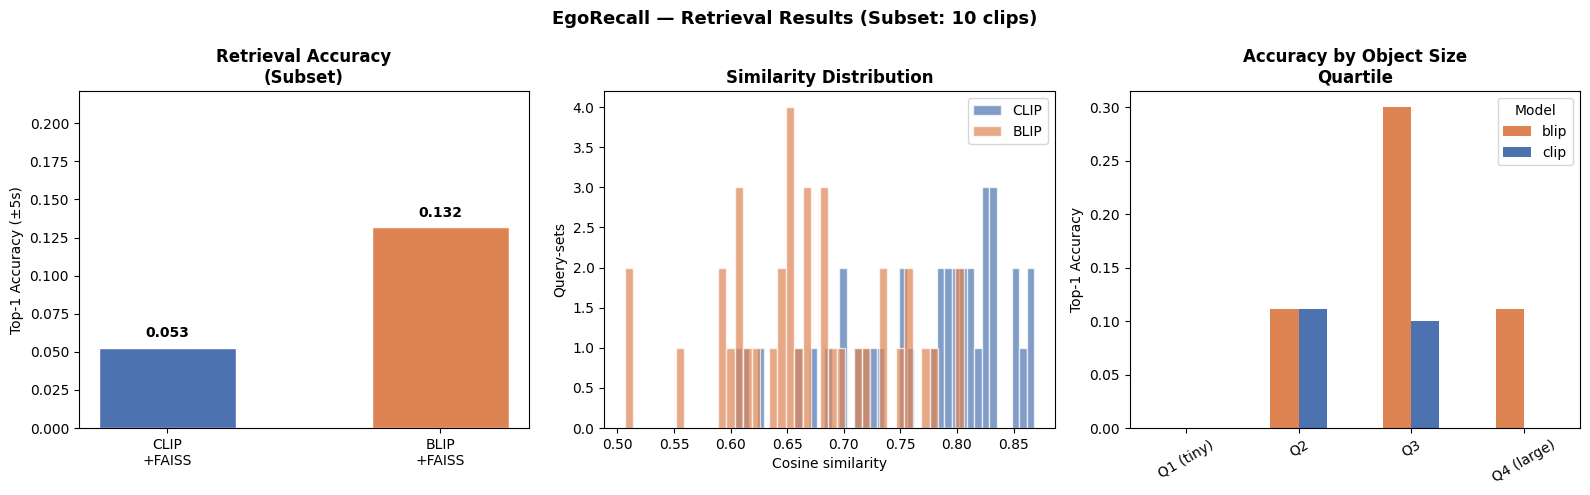

In [17]:
# ── Visualizations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {"clip": "#4C72B0", "blip": "#DD8452"}

# 1. Accuracy comparison
models = ["clip", "blip"]
accs   = [accuracy_by_model.loc[m, "Top-1 Accuracy"] for m in models]
bars   = axes[0].bar(
    ["CLIP\n+FAISS", "BLIP\n+FAISS"], accs,
    color=[colors[m] for m in models],
    edgecolor="white", width=0.5
)
for bar, val in zip(bars, accs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{val:.3f}", ha="center", va="bottom", fontweight="bold"
    )
axes[0].set_ylabel(f"Top-1 Accuracy (±{TOLERANCE_SEC}s)")
axes[0].set_title("Retrieval Accuracy\n(Subset)", fontweight="bold")
axes[0].set_ylim(0, max(accs) * 1.3 + 0.05)

# 2. Similarity score distributions
for model, color in colors.items():
    subset = results_df[results_df.model == model]["similarity"]
    axes[1].hist(subset, bins=40, alpha=0.7, color=color,
                 label=model.upper(), edgecolor="white")
axes[1].set_xlabel("Cosine similarity")
axes[1].set_ylabel("Query-sets")
axes[1].set_title("Similarity Distribution", fontweight="bold")
axes[1].legend()

# 3. Success rate by object normalized area quartile
# Merge with query-set metadata for area info
area_df = val_df[["annotation_uid", "qs_id", "vc_area_norm"]].copy()
merged  = results_df.merge(area_df, on=["annotation_uid", "qs_id"], how="left")
merged["area_quartile"] = pd.qcut(
    merged["vc_area_norm"].clip(upper=0.2),
    q=4, labels=["Q1 (tiny)", "Q2", "Q3", "Q4 (large)"]
)
area_acc = merged.groupby(["model", "area_quartile"])["success"].mean().unstack()
area_acc.T.plot(kind="bar", ax=axes[2],
                color=[colors[m] for m in area_acc.index])
axes[2].set_title("Accuracy by Object Size\nQuartile", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Top-1 Accuracy")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(title="Model")

plt.suptitle(
    f"EgoRecall — Retrieval Results (Subset: {N_CLIPS} clips)",
    fontweight="bold", fontsize=13
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "retrieval_subset_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# ── Top objects by retrieval success rate ──────────────────────────────────
obj_acc = results_df.groupby(["object_title", "model"])["success"].agg(
    ["mean", "count"]
).reset_index()
obj_acc.columns = ["object_title", "model", "accuracy", "count"]
obj_acc = obj_acc[obj_acc["count"] >= 3]  # min 3 queries for stability

print("Top-10 easiest objects (CLIP):")
clip_obj = obj_acc[obj_acc.model == "clip"].sort_values("accuracy", ascending=False)
print(clip_obj.head(10)[["object_title", "accuracy", "count"]].to_string(index=False))

print("\nTop-10 hardest objects (CLIP):")
print(clip_obj.tail(10)[["object_title", "accuracy", "count"]].to_string(index=False))

Top-10 easiest objects (CLIP):
Empty DataFrame
Columns: [object_title, accuracy, count]
Index: []

Top-10 hardest objects (CLIP):
Empty DataFrame
Columns: [object_title, accuracy, count]
Index: []


In [20]:
# ── Save results locally ───────────────────────────────────────────────────
from google.colab import files

local_parquet = "/content/retrieval_subset_results.parquet"
local_csv = "/content/retrieval_subset_results.csv"
local_summary = "/content/retrieval_subset_summary.csv"

# Save detailed per-query results
results_df.to_parquet(local_parquet, index=False)
results_df.to_csv(local_csv, index=False)

# Save summary metrics
accuracy_by_model.to_csv(local_summary)

print("── Final Results ─────────────────────────")
for model in ["clip", "blip"]:
    acc = results_df[results_df.model == model]["success"].mean()
    n = (results_df.model == model).sum()
    print(f"{model.upper():4s} Top-1 Accuracy: {acc:.4f}  ({n:,} queries)")

print(f"\nSubset: {N_CLIPS} val clips, ±{TOLERANCE_SEC}s tolerance")
print("Saved locally:")
print(local_parquet)
print(local_csv)
print(local_summary)

# Download files to your computer
files.download(local_parquet)
files.download(local_csv)
files.download(local_summary)

── Final Results ─────────────────────────
CLIP Top-1 Accuracy: 0.0526  (38 queries)
BLIP Top-1 Accuracy: 0.1316  (38 queries)

Subset: 10 val clips, ±5s tolerance
Saved locally:
/content/retrieval_subset_results.parquet
/content/retrieval_subset_results.csv
/content/retrieval_subset_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>